**Setup**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/fgvc-aircraft")
from utils import load_dataset, save_dataset

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


**Load dataset**

In [2]:
dataset = load_dataset()
print(f"Total samples: {len(dataset)}")

 100% |███████████████| 3334/3334 [1.3s elapsed, 0s remaining, 2.5K samples/s]         


INFO:eta.core.utils: 100% |███████████████| 3334/3334 [1.3s elapsed, 0s remaining, 2.5K samples/s]         


Loaded 3334 samples
Total samples: 3334


**Photos per aircraft**

In [3]:
labels = [s["ground_truth"]["label"] for s in dataset]
counts = pd.Series(labels).value_counts().sort_values(ascending=False)

print(f"Unique aircraft variants: {len(counts)}")
print(f"\nTop 10:\n{counts.head(10)}")
print(f"\nBottom 10:\n{counts.tail(10)}")
print(f"\nMin: {counts.min()} | Max: {counts.max()} | Mean: {counts.mean():.1f}")

Unique aircraft variants: 100

Top 10:
707-320     34
737-300     34
737-900     34
737-600     34
A340-300    34
A380        34
757-300     34
747-300     34
767-400     34
A330-200    34
Name: count, dtype: int64

Bottom 10:
MD-80         33
MD-11         33
PA-28         33
Metroliner    33
MD-90         33
SR-20         33
Spitfire      33
Saab 340      33
Tu-134        33
Tu-154        33
Name: count, dtype: int64

Min: 33 | Max: 34 | Mean: 33.3


Dataset - 100 unique aircraft variants
Even distribution of images per variant

**Chart per aircraft**

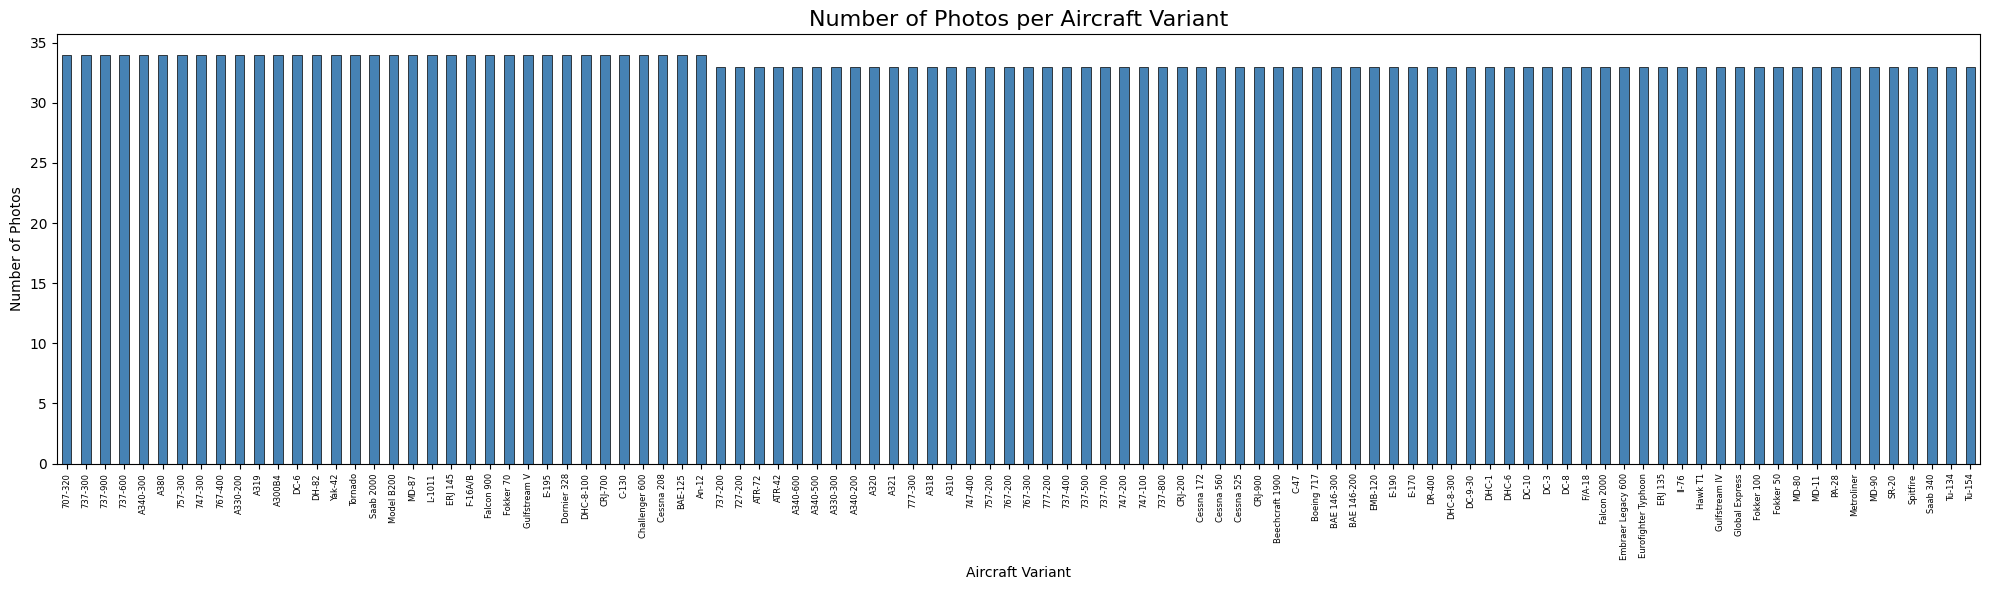

In [4]:
fig, ax = plt.subplots(figsize=(20, 6))
counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_title("Number of Photos per Aircraft Variant", fontsize=16)
ax.set_xlabel("Aircraft Variant")
ax.set_ylabel("Number of Photos")
ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

Chart shows almost even distribution between all types

**Top/bottom 5**

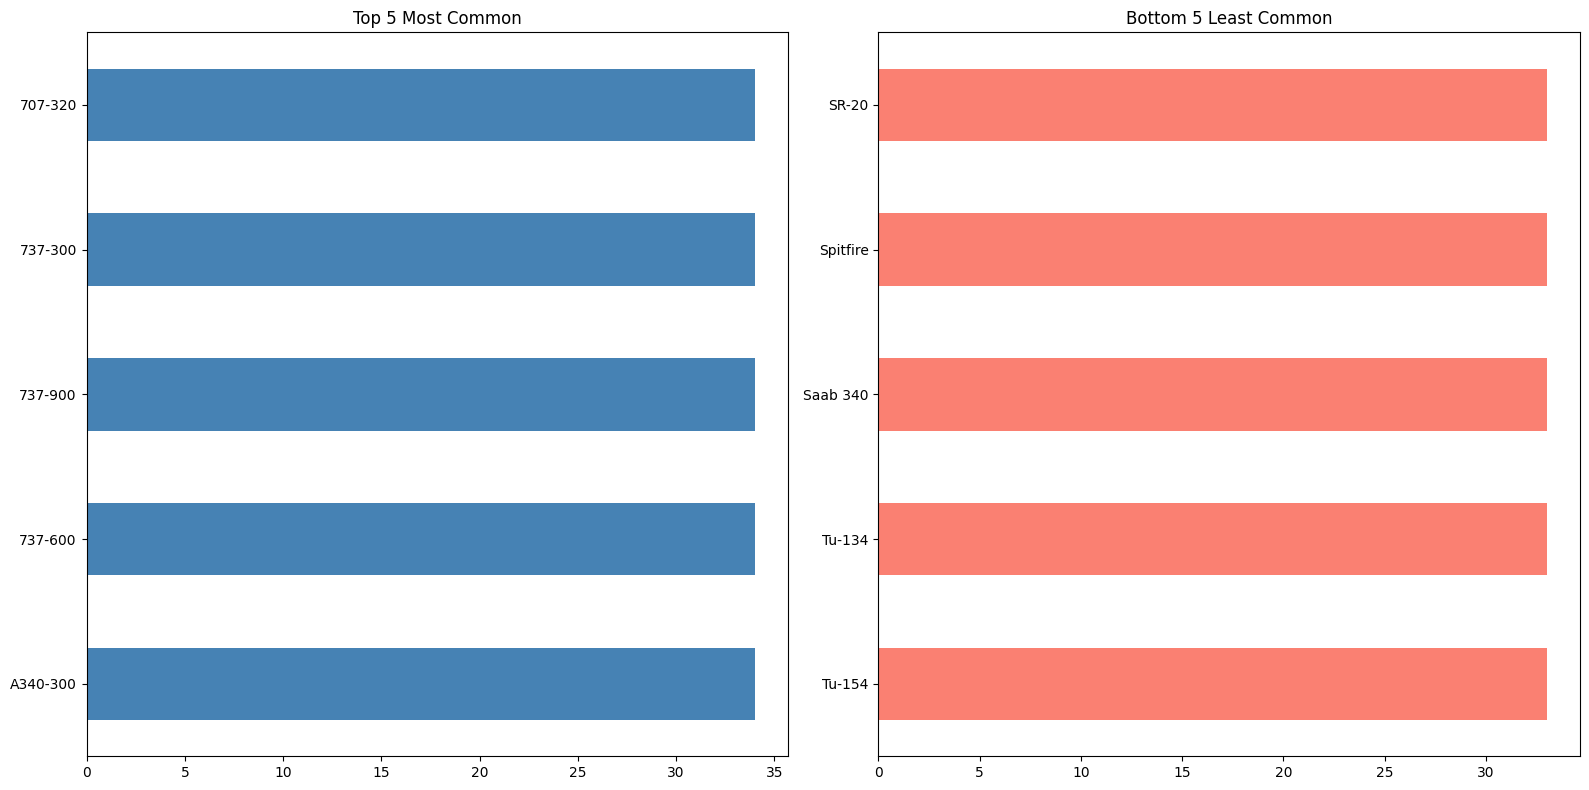

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

counts.head(5).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 5 Most Common")
axes[0].invert_yaxis()

counts.tail(5).plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Bottom 5 Least Common")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Broken images check**

In [6]:
broken  = []
missing = []
ok      = 0

for sample in dataset:
    path = sample.filepath
    if not os.path.exists(path):
        missing.append(path)
        continue
    try:
        with Image.open(path) as img:
            img.verify()
        ok += 1
    except Exception as e:
        broken.append({"filepath": path, "error": str(e)})

print(f"✅ OK: {ok}")
print(f"❌ Broken: {len(broken)}")
print(f"🔍 Missing: {len(missing)}")

# Remove bad samples
bad_paths = set([b["filepath"] for b in broken] + missing)
if bad_paths:
    bad_ids = [s.id for s in dataset if s.filepath in bad_paths]
    dataset.delete_samples(bad_ids)
    print(f"Removed {len(bad_ids)} bad samples. Dataset now has {len(dataset)} samples.")
else:
    print("Dataset is clean!")

KeyboardInterrupt: 

Test shows no broken images

**Display random samples**

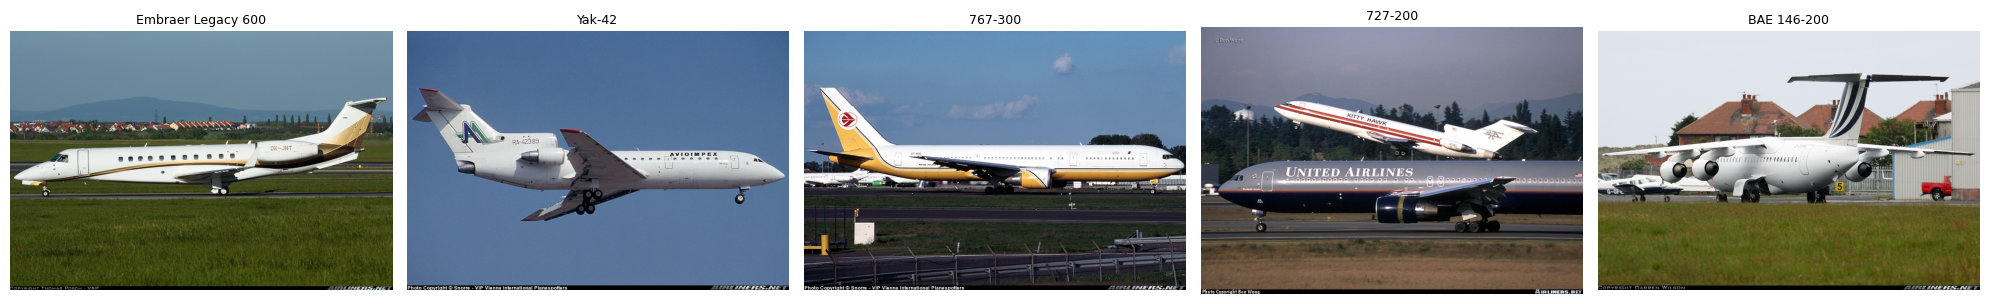

In [8]:
def show_random_samples(dataset, n=5, cols=5):
    rows    = (n + cols - 1) // cols
    samples = random.sample(list(dataset), n)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for ax, sample in zip(axes, samples):
        img = Image.open(sample.filepath)
        ax.imshow(img)
        ax.set_title(sample.ground_truth.label, fontsize=9, wrap=True)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(dataset, n=5, cols=5)

Random display shows images loading as intended.

**Save to pickle**

In [9]:
save_dataset(dataset)

Saved 3334 samples to pickle
